In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
import pyproj

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [2]:
# For transforming lon/lat coordinates to x/y coordinate in feet suitable for Pennsylvania
# https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset
# EPSG:4326 - https://epsg.io/4326
# EPSG:2272 - https://epsg.io/2272
transformer_ll_to_xy = pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:2272', always_xy=True)

In [3]:
# https://data.wprdc.org/dataset/city-trees/resource/1515a93c-73e3-4425-9b35-1cd11b2196da
df_trees_raw = pd.read_csv('./data/wprdc-city-trees/trees-1515a93c-73e3-4425-9b35-1cd11b2196da.csv', dtype={
    'address_number': 'string',
    'tract': 'string',
})
df_trees_raw[['x', 'y']] = df_trees_raw.apply(lambda row: transformer_ll_to_xy.transform(row['longitude'], row['latitude']), axis=1, result_type='expand')
print('Records:', len(df_trees_raw))
print('Columns:', list(df_trees_raw.columns))
df_trees_raw[:1]

Records: 45709
Columns: ['_id', 'id', 'address_number', 'street', 'common_name', 'scientific_name', 'height', 'width', 'growth_space_length', 'growth_space_width', 'growth_space_type', 'diameter_base_height', 'stems', 'overhead_utilities', 'land_use', 'condition', 'stormwater_benefits_dollar_value', 'stormwater_benefits_runoff_elim', 'property_value_benefits_dollarvalue', 'property_value_benefits_leaf_surface_area', 'energy_benefits_electricity_dollar_value', 'energy_benefits_gas_dollar_value', 'air_quality_benfits_o3dep_dollar_value', 'air_quality_benfits_o3dep_lbs', 'air_quality_benfits_vocavd_dollar_value', 'air_quality_benfits_vocavd_lbs', 'air_quality_benfits_no2dep_dollar_value', 'air_quality_benfits_no2dep_lbs', 'air_quality_benfits_no2avd_dollar_value', 'air_quality_benfits_no2avd_lbs', 'air_quality_benfits_so2dep_dollar_value', 'air_quality_benfits_so2dep_lbs', 'air_quality_benfits_so2avd_dollar_value', 'air_quality_benfits_so2avd_lbs', 'air_quality_benfits_pm10depdollar_value

,_id,id,address_number,street,common_name,scientific_name,height,width,growth_space_length,growth_space_width,growth_space_type,diameter_base_height,stems,overhead_utilities,land_use,condition,stormwater_benefits_dollar_value,stormwater_benefits_runoff_elim,property_value_benefits_dollarvalue,property_value_benefits_leaf_surface_area,energy_benefits_electricity_dollar_value,energy_benefits_gas_dollar_value,air_quality_benfits_o3dep_dollar_value,air_quality_benfits_o3dep_lbs,air_quality_benfits_vocavd_dollar_value,air_quality_benfits_vocavd_lbs,air_quality_benfits_no2dep_dollar_value,air_quality_benfits_no2dep_lbs,air_quality_benfits_no2avd_dollar_value,air_quality_benfits_no2avd_lbs,air_quality_benfits_so2dep_dollar_value,air_quality_benfits_so2dep_lbs,air_quality_benfits_so2avd_dollar_value,air_quality_benfits_so2avd_lbs,air_quality_benfits_pm10depdollar_value,air_quality_benfits_pm10dep_lbs,air_quality_benfits_pm10avd_dollar_value,air_quality_benfits_pm10avd_lbs,air_quality_benfits_total_dollar_value,air_quality_benfits_total_lbs,co2_benefits_dollar_value,co2_benefits_sequestered_lbs,co2_benefits_sequestered_value,co2_benefits_avoided_lbs,co2_benefits_avoided_value,co2_benefits_decomp_lbs,co2_benefits_maint_lbs,co2_benefits_totalco2_lbs,overall_benefits_dollar_value,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude,x,y
0,1,754166088,7428,MONTICELLO ST,Stump,Stump,0.0,0.0,10.0,2.0,Well or Pit,16.0,1.0,Yes,Vacant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Homewood North,9.0,13.0,42003130200,2.0,13.0,5.0,3-17,40.458169,-79.889724,1.373137e+06,416976.499645


In [4]:
df_trees_raw["growth_space_type"].value_counts()

growth_space_type
Open or Unrestricted    15897
Well or Pit             14099
Tree Lawn or Parkway    12613
Open or Restricted       1456
Median                    783
Natural Area              280
Well/Pit                  170
Island                     82
Tree Lawn                  60
Raised Planter             54
Open                       21
Other - see notes           1
Name: count, dtype: int64

In [5]:
df_trees_raw["condition"].value_counts()

condition
Good         16404
Fair         16233
Poor          4615
Dead          1100
Critical       988
Very Good      554
Excellent       79
Name: count, dtype: int64

In [8]:
neighborhoods = df_trees_raw["neighborhood"].value_counts()
print(neighborhoods[:5])

neighborhood
Squirrel Hill South    5073
Highland Park          2941
Squirrel Hill North    2083
South Side Flats       1693
Shadyside              1558
Name: count, dtype: int64


In [11]:
df_trees_raw["land_use"].value_counts()

land_use
Residential                 26223
Park or Public Space         5346
Commercial/Industrial        5281
Vacant                       2469
Multi-family Residential     1743
Institutional                1626
Street                       1302
Park                         1013
Transportation                107
Cemetery                       87
Agriculture                    24
Utility                        15
Other                          15
Golf Course                    13
Water/Wetland                   1
Name: count, dtype: int64

In [16]:
df_trees = df_trees_raw[
    (df_trees_raw["common_name"] != "Vacant Site Small")
    & (df_trees_raw["common_name"] != "Vacant Site Large")
    & (df_trees_raw["common_name"] != "Non-sufficient space")
    & (df_trees_raw["common_name"] != "Stump")
    & (df_trees_raw["condition"] != "Dead")
]
# TODO - growth_space_type: "Open" -> "Open or Unrestricted" and "Well/Pit" -> "Well or Pit"
print('Records:', len(df_trees))
print('Columns:', list(df_trees.columns))
df_trees[:1]

Records: 40556
Columns: ['_id', 'id', 'address_number', 'street', 'common_name', 'scientific_name', 'height', 'width', 'growth_space_length', 'growth_space_width', 'growth_space_type', 'diameter_base_height', 'stems', 'overhead_utilities', 'land_use', 'condition', 'stormwater_benefits_dollar_value', 'stormwater_benefits_runoff_elim', 'property_value_benefits_dollarvalue', 'property_value_benefits_leaf_surface_area', 'energy_benefits_electricity_dollar_value', 'energy_benefits_gas_dollar_value', 'air_quality_benfits_o3dep_dollar_value', 'air_quality_benfits_o3dep_lbs', 'air_quality_benfits_vocavd_dollar_value', 'air_quality_benfits_vocavd_lbs', 'air_quality_benfits_no2dep_dollar_value', 'air_quality_benfits_no2dep_lbs', 'air_quality_benfits_no2avd_dollar_value', 'air_quality_benfits_no2avd_lbs', 'air_quality_benfits_so2dep_dollar_value', 'air_quality_benfits_so2dep_lbs', 'air_quality_benfits_so2avd_dollar_value', 'air_quality_benfits_so2avd_lbs', 'air_quality_benfits_pm10depdollar_value

,_id,id,address_number,street,common_name,scientific_name,height,width,growth_space_length,growth_space_width,growth_space_type,diameter_base_height,stems,overhead_utilities,land_use,condition,stormwater_benefits_dollar_value,stormwater_benefits_runoff_elim,property_value_benefits_dollarvalue,property_value_benefits_leaf_surface_area,energy_benefits_electricity_dollar_value,energy_benefits_gas_dollar_value,air_quality_benfits_o3dep_dollar_value,air_quality_benfits_o3dep_lbs,air_quality_benfits_vocavd_dollar_value,air_quality_benfits_vocavd_lbs,air_quality_benfits_no2dep_dollar_value,air_quality_benfits_no2dep_lbs,air_quality_benfits_no2avd_dollar_value,air_quality_benfits_no2avd_lbs,air_quality_benfits_so2dep_dollar_value,air_quality_benfits_so2dep_lbs,air_quality_benfits_so2avd_dollar_value,air_quality_benfits_so2avd_lbs,air_quality_benfits_pm10depdollar_value,air_quality_benfits_pm10dep_lbs,air_quality_benfits_pm10avd_dollar_value,air_quality_benfits_pm10avd_lbs,air_quality_benfits_total_dollar_value,air_quality_benfits_total_lbs,co2_benefits_dollar_value,co2_benefits_sequestered_lbs,co2_benefits_sequestered_value,co2_benefits_avoided_lbs,co2_benefits_avoided_value,co2_benefits_decomp_lbs,co2_benefits_maint_lbs,co2_benefits_totalco2_lbs,overall_benefits_dollar_value,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude,x,y
1,2,1946899269,220,BALVER AVE,Linden: Littleleaf,Tilia cordata,0.0,0.0,99.0,99.0,Open or Unrestricted,22.0,0.0,No,Residential,NaN,13.946694,1743.336782,21.984813,36.538333,15.776457,61.068319,2.360847,0.514346,0.072138,0.031229,0.992384,0.216206,3.702306,0.806603,0.274901,0.078994,1.407724,0.404518,2.185328,0.262976,0.46181,0.055573,11.457438,2.370444,0.944601,115.328075,0.847431,277.540793,2.03937,-96.345471,-13.708796,282.8146,125.178322,Oakwood,2.0,28.0,42003562800,5.0,28.0,6.0,1-19,40.429269,-80.067868,1.323304e+06,407702.900761


In [75]:
def plot_map(df, colorizer=None, labeler=None, df_background=None, title=None, figsize=(10, 10)):
    fig, ax = plt.subplots(figsize=figsize)

    if title:
        ax.set_title(title)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v/1000:.0f}'))
    ax.set_xlabel("Thousands of Feet")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v/1000:.0f}'))
    ax.set_ylabel("Thousands of Feet")
    if df_background is not None:
        ax.scatter(df_background["x"], df_background["y"], color=(0.8, 0.8, 0.8), s=0.1)
    colors = None
    if colorizer is not None:
        colors = [colorizer(row) for _, row in df.iterrows()]

    labels = None
    if labeler is not None:
        labels = [labeler(row) for _, row in df.iterrows()]
        ls = set(labels)
        
    ax.scatter(df["x"], df["y"], c=colors, s=0.1)
     
    plt.show()

def plot_maps(dfs, labels=None, df_bg=None, title=None, figsize=(10, 10)):
    fig, ax = plt.subplots(figsize=figsize)

    if title:
        ax.set_title(title)

    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v/1000:.0f}'))
    ax.set_xlabel("Thousands of Feet")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v/1000:.0f}'))
    ax.set_ylabel("Thousands of Feet")
    
    if df_bg is not None:
        ax.scatter(df_bg["x"], df_bg["y"], color=(0.8, 0.8, 0.8), s=0.1)

    for i, df in enumerate(dfs):
        label = None
        if labels is not None:
            label = labels[i]
        ax.scatter(df["x"], df["y"], label=label, s=0.1)

    if labels is not None:
        plt.legend(markerscale=8)
     
    plt.show()

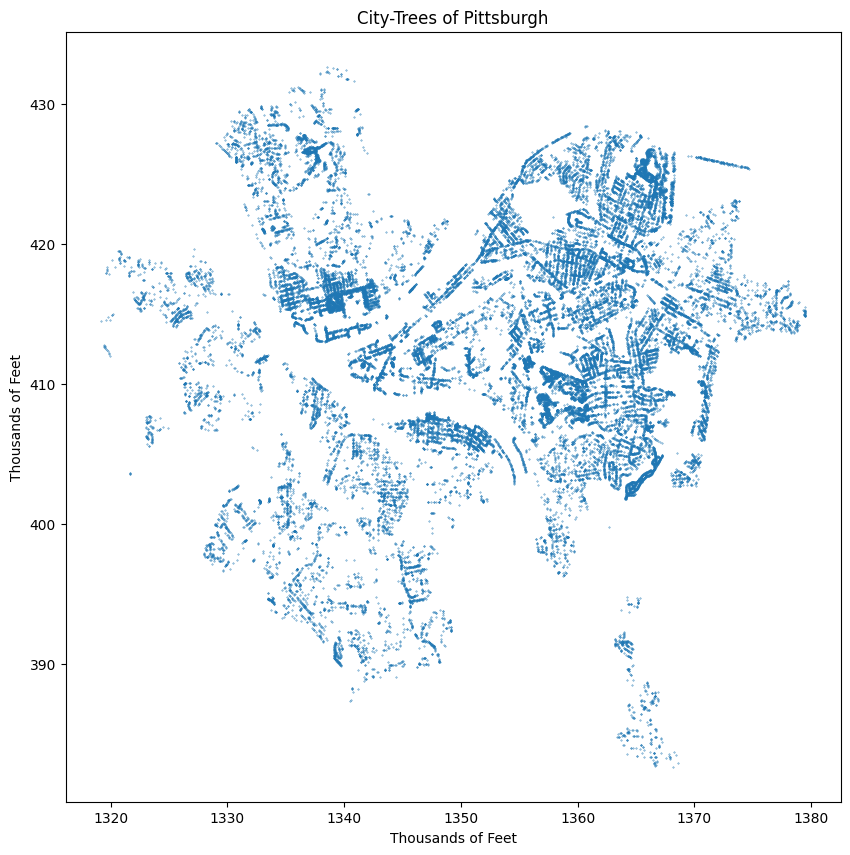

In [76]:
plot_map(
    df_trees,
    title="City-Trees of Pittsburgh",
)

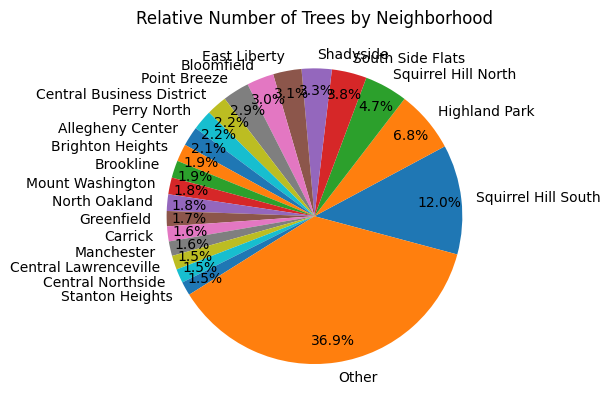

In [105]:
df_labeled = df_trees["neighborhood"]
df_labeled_counts = df_labeled.value_counts()

threshold = 600 # Determined by fiddling.
df_labeled_filtered = df_labeled_counts[df_labeled_counts >= threshold]
df_labeled_others = df_labeled_counts[df_labeled_counts < threshold].sum()

df_labeled_final = df_labeled_filtered.copy()
if df_labeled_others > 0:
    df_labeled_final["Other"] = df_labeled_others

ax = df_labeled_final.plot.pie(
    title="Relative Number of Trees by Neighborhood",
    autopct="%1.1f%%",
    pctdistance=0.85,  # Determined by fiddling.
    startangle=-15.0,  # Determined by fiddling.
)
ax.set_ylabel("")
pass

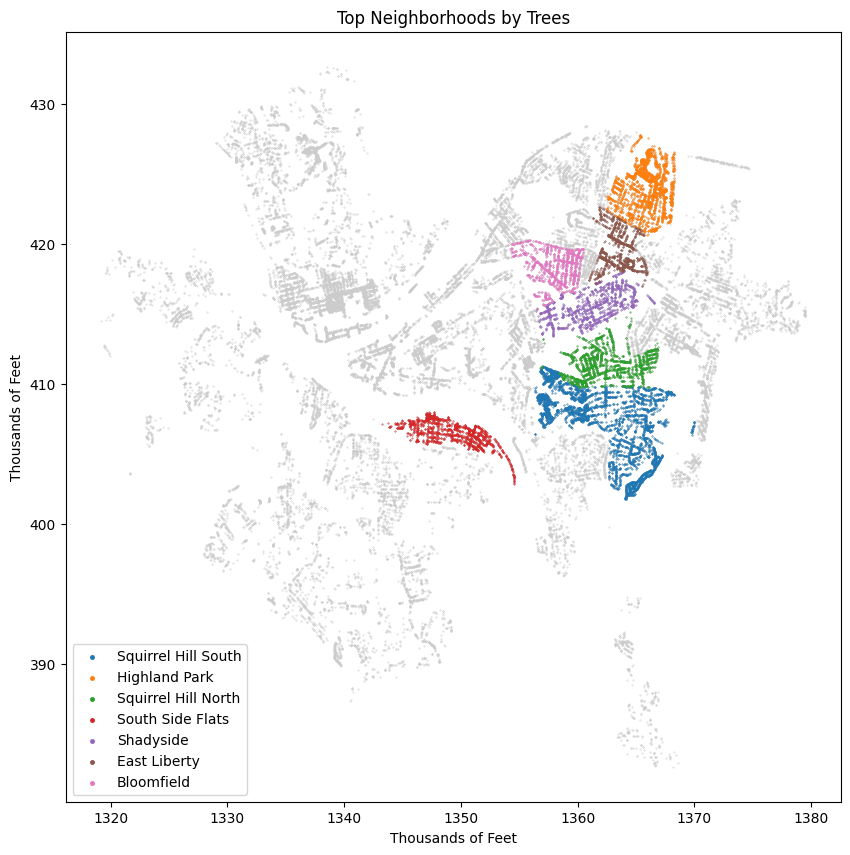

In [109]:
top_neighborhoods = df_trees["neighborhood"].value_counts()
top_neighborhoods = list(top_neighborhoods[:7].keys()) 

dfs_top_neighborhoods = []
labels = []
for neighborhood in top_neighborhoods:
    dfs_top_neighborhoods.append(
        df_trees[df_trees["neighborhood"] == neighborhood]
    )
    labels.append(neighborhood)

plot_maps(
    dfs_top_neighborhoods,
    labels,
    df_bg=df_trees,
    title="Top Neighborhoods by Trees",
)

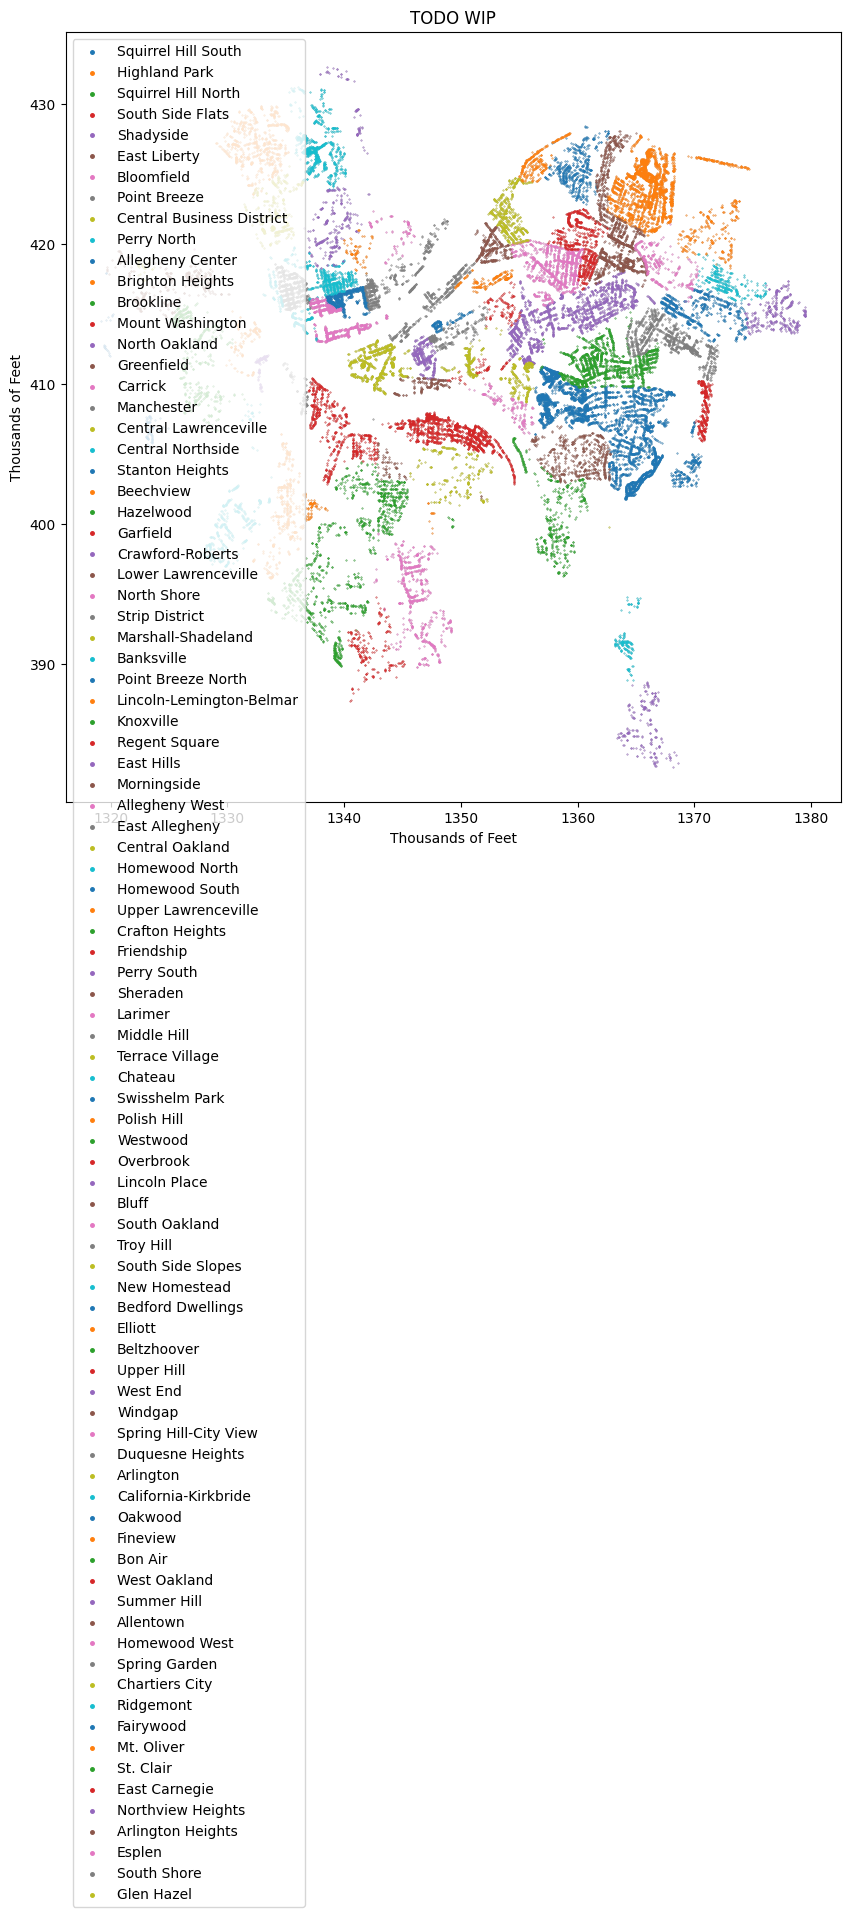

In [110]:
# TODO - WORK IN PROGRESS, WANT TO SHOW DOWNTOWN NEIGHBORHOODS ONLY
top_neighborhoods = df_trees["neighborhood"].value_counts()
top_neighborhoods = list(top_neighborhoods.keys()) 

dfs_top_neighborhoods = []
labels = []
for neighborhood in top_neighborhoods:
    dfs_top_neighborhoods.append(
        df_trees[df_trees["neighborhood"] == neighborhood]
    )
    labels.append(neighborhood)

plot_maps(
    dfs_top_neighborhoods,
    labels,
    df_bg=df_trees,
    title="TODO WIP",
)

In [14]:
common_trees = df_trees["common_name"].value_counts()

print(common_trees[:10])
print()
print(common_trees[-10:])
print()

common_name
Maple: Norway             3623
Maple: Red                3351
London planetree          3226
Pear: Callery             2924
Linden: Littleleaf        2393
Honeylocust: Thornless    2009
Oak: Pin                  1661
Crabapple: Flowering      1283
Ginkgo                    1200
Oak: Northern Red          972
Name: count, dtype: int64

common_name
Maple: Shantung                      1
Magnolia: Bigleaf                    1
Evodia: Korean                       1
Falsecypress: Lawson                 1
Juniper: spp.                        1
Larch: Golden                        1
Dogwood: spp.                        1
Elm: Winged                          1
Crabapple: Donald Wyman Flowering    1
Mulberry: Paper                      1
Name: count, dtype: int64



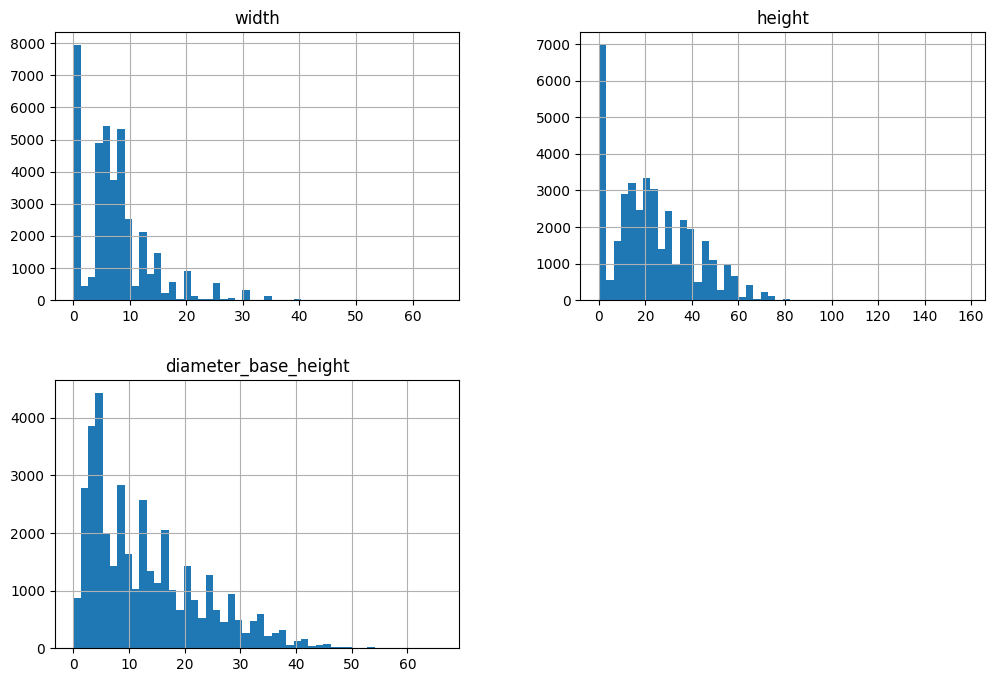

In [15]:
# We see for width/height, there are many "0" entries. However, diameter_base_height is a normal
# looking plot.
df_trees[["width", "height", "diameter_base_height"]].hist(bins=50, figsize=(12, 8))
plt.show()

In [12]:
# ---- SCRATCH WORK ------

In [13]:
what = df_trees[
    (df_trees["width"] == 0.0) & (df_trees["height"] > 0.0)
]
what[:1]

,_id,id,address_number,street,common_name,scientific_name,height,width,growth_space_length,growth_space_width,growth_space_type,diameter_base_height,stems,overhead_utilities,land_use,condition,stormwater_benefits_dollar_value,stormwater_benefits_runoff_elim,property_value_benefits_dollarvalue,property_value_benefits_leaf_surface_area,energy_benefits_electricity_dollar_value,energy_benefits_gas_dollar_value,air_quality_benfits_o3dep_dollar_value,air_quality_benfits_o3dep_lbs,air_quality_benfits_vocavd_dollar_value,air_quality_benfits_vocavd_lbs,air_quality_benfits_no2dep_dollar_value,air_quality_benfits_no2dep_lbs,air_quality_benfits_no2avd_dollar_value,air_quality_benfits_no2avd_lbs,air_quality_benfits_so2dep_dollar_value,air_quality_benfits_so2dep_lbs,air_quality_benfits_so2avd_dollar_value,air_quality_benfits_so2avd_lbs,air_quality_benfits_pm10depdollar_value,air_quality_benfits_pm10dep_lbs,air_quality_benfits_pm10avd_dollar_value,air_quality_benfits_pm10avd_lbs,air_quality_benfits_total_dollar_value,air_quality_benfits_total_lbs,co2_benefits_dollar_value,co2_benefits_sequestered_lbs,co2_benefits_sequestered_value,co2_benefits_avoided_lbs,co2_benefits_avoided_value,co2_benefits_decomp_lbs,co2_benefits_maint_lbs,co2_benefits_totalco2_lbs,overall_benefits_dollar_value,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude,x,y
147,148,506199472,1408,ARCH ST,Serviceberry: Eastern,Amelanchier canadensis,6.0,0.0,4.0,4.0,Well or Pit,2.0,1.0,No,Institutional,Very Good,0.207837,25.979579,8.991322,14.943402,0.782313,4.241051,0.009442,0.002057,0.00038,0.000165,0.004082,0.000889,0.018488,0.004028,0.001175,0.000338,0.005971,0.001716,0.041966,0.00505,0.011075,0.001333,0.09258,0.015575,0.005951,0.771565,0.005669,1.174849,0.008633,-0.058393,-0.106388,1.781634,14.321053,Central Northside,6.0,25.0,42003250300,1.0,25.0,1.0,1-21,40.457611,-80.009326,1.339860e+06,417602.184258


In [9]:
# TODO - What neighborhoods are by downtown?

# TODO - Where are the "excellent" trees?
# TODO - Where are the "island" trees?
# TODO - Where are the "tree lawn" trees?
# TODO - Where's the lake/wetlands tree? (I think it might be a baldcyprus)
# TODO - Pie charts for tree species
# TODO - maybe look at native/non-native
# TODO - look at condition column
# TODO - Find Thicccccc Trees
# TODO - Plot by Land Use
# TODO - Plot by Condition
# TODO - Plot by Neighborhood
# TODO - Plot by Fire Zone

In [70]:
# FINDINGS
#
# * If I want to see more trees, go to the east part of the city.
#   - something in squirrel hill south would be great